Newton

In [1]:
def f(x): return x**2-2
def d_f(x): return 2*x

x0 = 1
i = 1
ITER, EPS = 100, 1e-5

while abs(f(x0)) >= EPS and i <= ITER:
    sol = x0 - f(x0)/d_f(x0)
    x0 = sol
    i += 1

sol

1.4142156862745099

Bisection

In [2]:
def f(x): return x**2-2

a,b = 1,4
c,i =(a+b)/2,1
ITER, EPS, DLT = 100, 1e-5, 1e-5

while abs(b-a) >= DLT and abs(f(c)) >= EPS and i <= ITER:
    
    if f(c) == 0: break
    elif f(c)*f(a) < 0: b=c
    else: a=c

    sol = c
    c = (a+b)/2
    i += 1

sol

1.4142189025878906

Fixed point

In [3]:
def f(x): return (3*x**2+3)**(1/4)

x0 = 1
x = f(x0)
ITER, EPS, i = 100, 1e-3, 1

while i <= ITER and abs(x-x0) >= EPS:

    temp_root=x
    temp_error=abs(x-x0)
    x0=x
    x=f(x0)
    i=i+1

print("root:",temp_root)
print("error:",temp_error)

root: 1.9456168565210508
error: 0.0022999266223739934


Bifurcation diagram of the logistic map

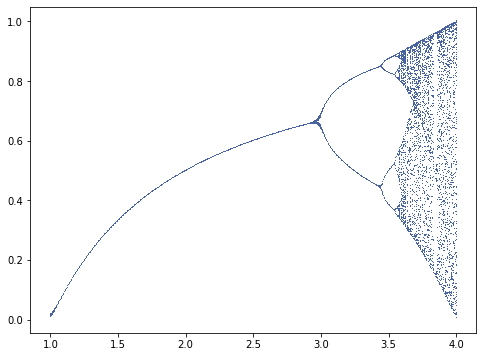

In [4]:
import matplotlib.pyplot as plt 

a,b = 1,4
N,R = [],[]

plt.figure(figsize=(8,6))
while a <= b:
    x=0.5
    for i in range(100):
        x = a*x*(1-x)
        if i > 100/2:
            N.append(x)
            R.append(a)

    plt.plot(R,N,',', color="#4863A0")
    a += 0.005
plt.show()

Gaussian elimation

In [5]:
import numpy as np 
from fractions import Fraction

#設定矩陣元素輸出用分數表示
np.set_printoptions(formatter={'all':lambda x: str(Fraction(x).limit_denominator())})

# x -2y +3z = 5
# 2x +y -3z = -3
# 3x -y +2z = 6

A = np.array([[1,-2,3],
              [2,1,-3],
              [3,-1,2]],dtype=float) 

B = np.array([[5],
              [-3],
              [6]],dtype=float)
              
X = np.zeros((3,1),dtype=float)

C = np.hstack([A,B]) #增廣矩陣
n= np.size(X)

# Gaussian Elimation
check = True

for kk in np.arange(0,n):

    # 找出pivot最大的row
    pivot=np.array(abs(C[kk:n,kk]))
    Max_pivot=max(pivot)
    Max_row=np.where(pivot==Max_pivot)+kk

    # 由大到小重新排列row
    if Max_row != kk:
        temp = np.array(C[kk,:])
        C[kk,:] = C[Max_row,:]
        C[Max_row,:] = temp
    
    # 若整行為0則有一未知數沒有係數
    if Max_pivot == 0:
        print("Matrix is singular.")
        check = False
        break

    # 消去法
    t = C[kk+1:n,kk] / C[kk,kk]
    ts= np.size(t)
    tt= t.reshape((ts,1)) # t的轉置矩陣

    C[kk+1:n,kk]=0
    C[kk+1:n,kk+1:n+1] = C[kk+1:n,kk+1:n+1] - np.dot(tt,[C[kk,kk+1:n+1]])

# Backward Substitution
m = n-1 # python starts with 0

if check == True:
    X[m] = C[m,n] / C[m,m] # 先解最後一項
    for ii in np.arange(m-1,-1,-1):
        X[ii] = (C[ii,n] - np.dot(C[ii,ii+1:n],X[ii+1:n])) / C[ii,ii]       

X


array([[1],
       [1],
       [2]])